# REXAI Project - Session 1

## 1. Importing Libraries and Dataset

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Exploration and Visualization

In [ ]:
df = pd.read_csv("data/RH_dataset.csv", sep=";", encoding="utf-8")
df.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  str    
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  str    
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  label       

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=[str]).columns
assert len(num_cols) + len(cat_cols) == df.shape[1], "Some columns are not categorized correctly."

In [30]:
col_to_category = {}
for col in cat_cols:
    unique_values = df[col].unique().tolist()
    col_to_category[col] = unique_values
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Famille d'emploi, Unique Values: ['Production', 'Commercial/Business', 'Etudes & Technique', 'Support', 'IT', 'Développement Immobilier', 'Matériel/Equipement', 'Management']
Column: Statut marital, Unique Values: ['Marié(e)', 'PACS', 'Célibataire', 'Divorcé(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'Veuf(ve)', 'ex PACS']


In [39]:
# Hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df_encoded.head()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,...,Famille d'emploi_Support,Statut marital_Concubin,Statut marital_Célibataire,Statut marital_Divorcé(e),Statut marital_Marié(e),Statut marital_PACS,Statut marital_Séparé(e),Statut marital_Union libre,Statut marital_Veuf(ve),Statut marital_ex PACS
0,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,0,...,0,0,0,0,1,0,0,0,0,0
1,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,1,...,0,0,0,0,1,0,0,0,0,0
2,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,1,...,0,0,0,0,0,1,0,0,0,0
3,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,0,...,0,0,1,0,0,0,0,0,0,0
4,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,1,...,0,0,0,0,1,0,0,0,0,0


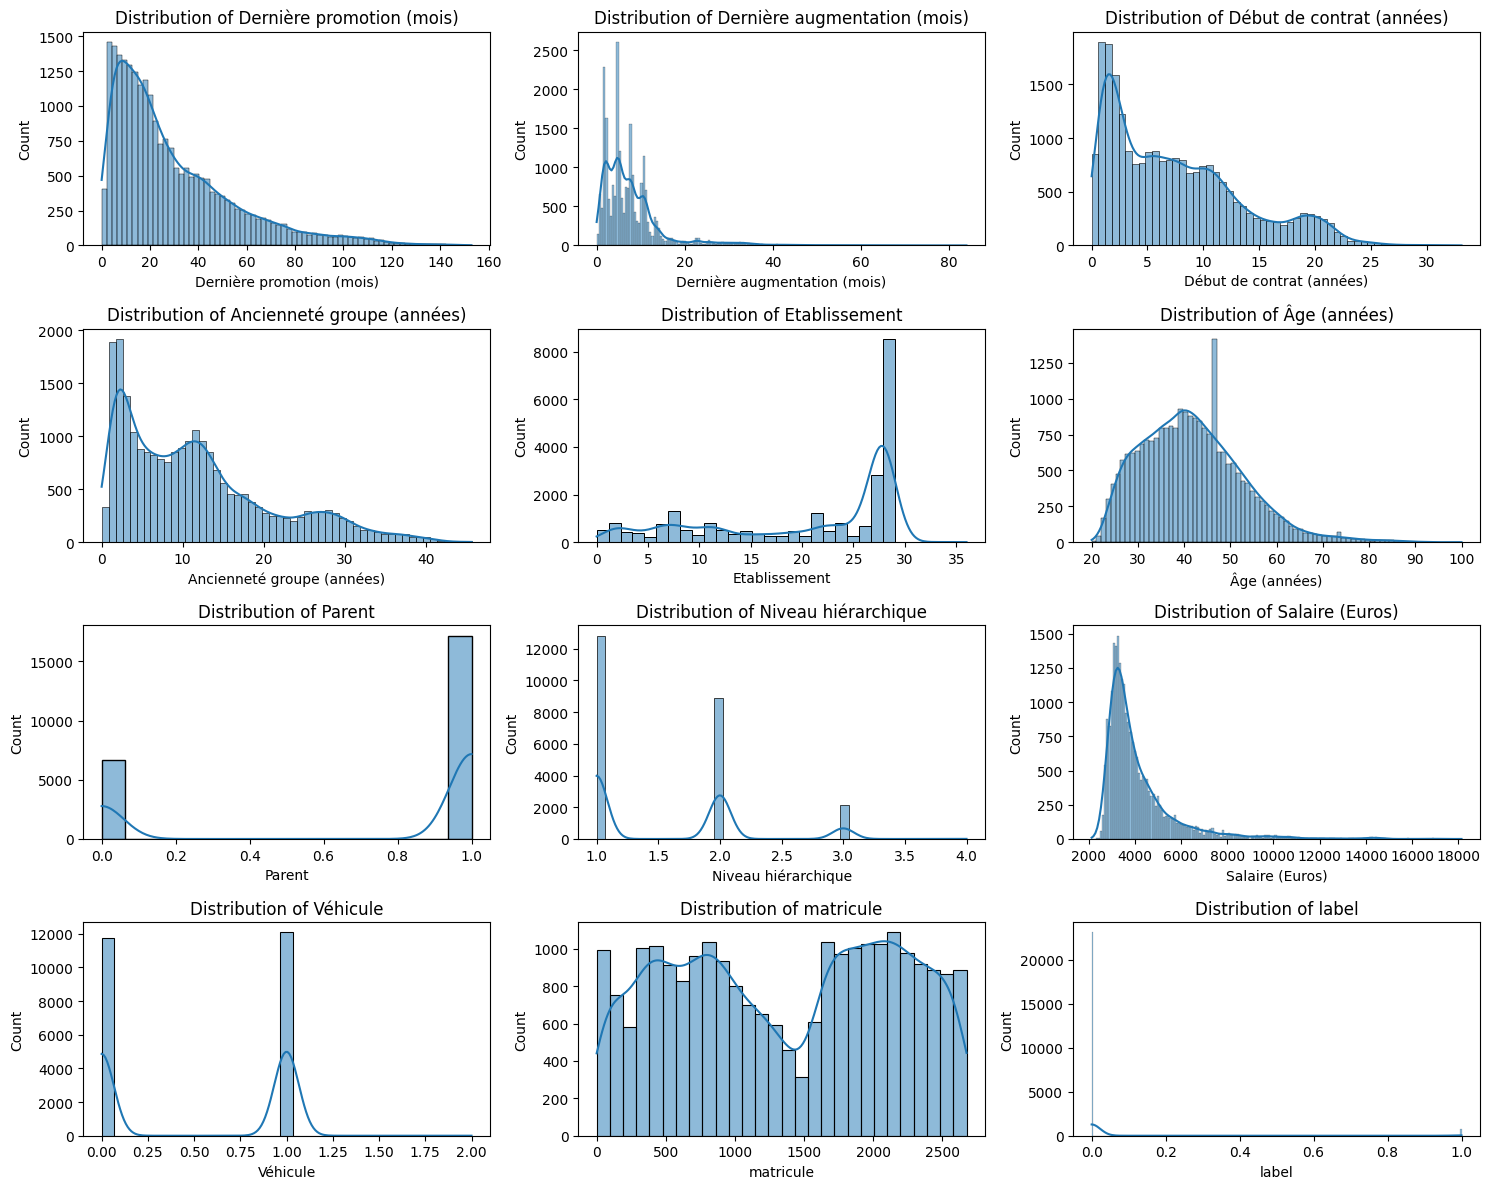

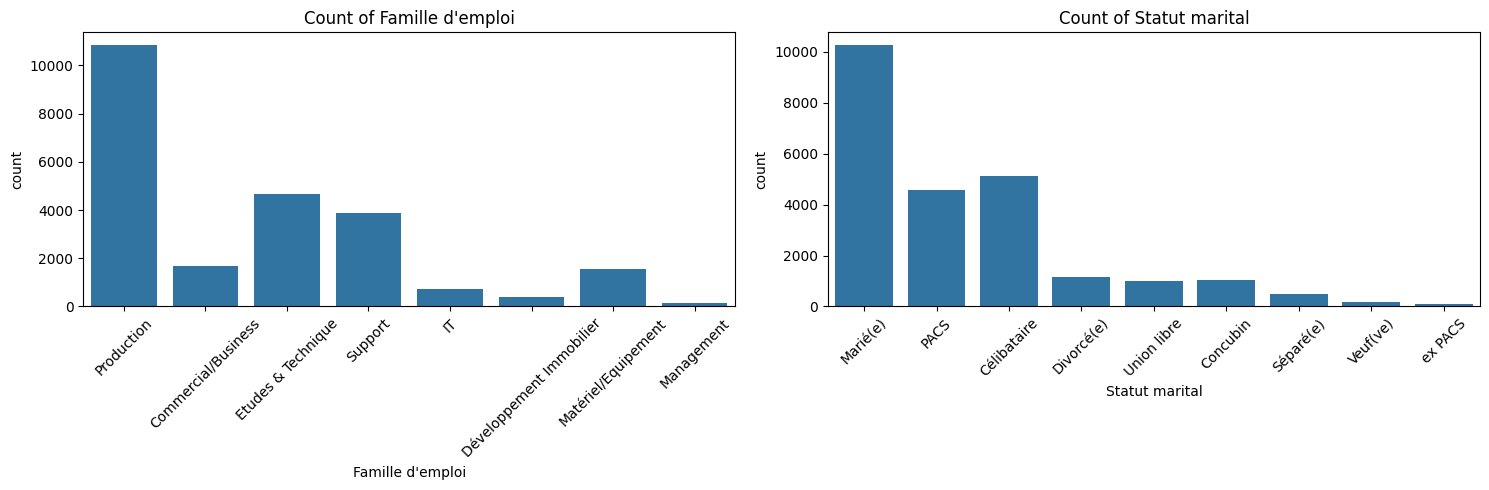

In [40]:
# Plot on the same figure in grid mode
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Show histograms for categorical variables
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

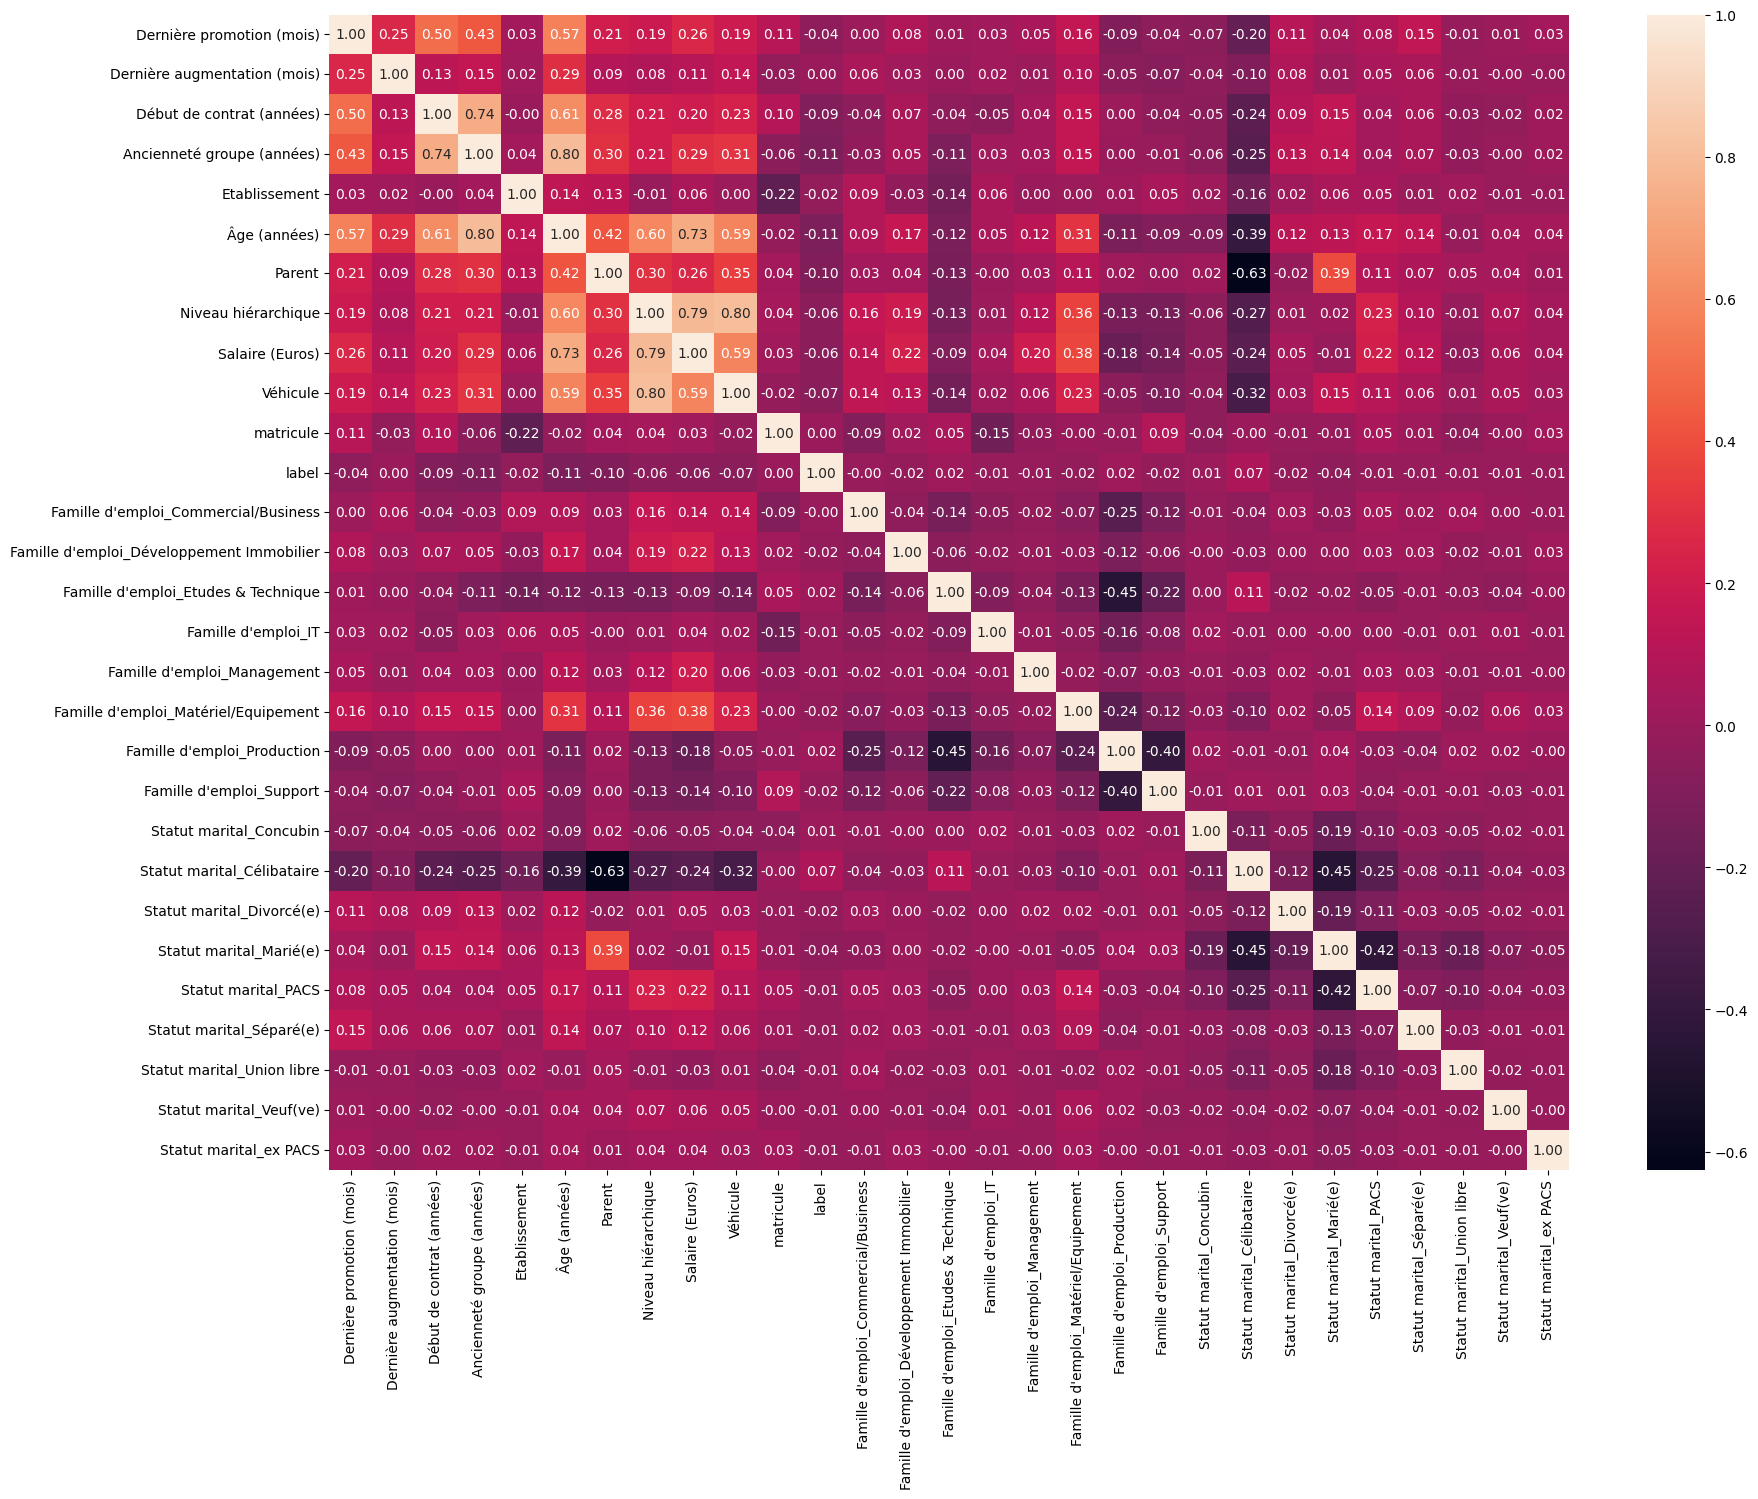

In [41]:
# Increase figure size for better readability
plt.figure(figsize=(20, 15))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f")
plt.show()